In [1]:
import pandas as pd
import numpy as np

In [2]:
customers = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/customers.csv")
articles = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/articles.csv")
transactions = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/transactions_train.csv")

print(customers.shape)
print(articles.shape)
print(transactions.shape)

(1371980, 7)
(105542, 25)
(31788324, 5)


In [3]:
customers.head()


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [4]:
articles.head()


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [5]:
customers.isnull().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [6]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [7]:
customers.drop(columns=['FN'], inplace=True)
customers.drop(columns=["Active"], inplace=True)

customers["club_member_status"] = (
    customers["club_member_status"]
    .fillna("UNKNOWN"))

customers["fashion_news_frequency"] = (
    customers["fashion_news_frequency"]
    .fillna("NONE"))



In [8]:
# Safe drop — won't crash if column doesn't exist
cols_to_drop = ['FN', 'Active']
customers.drop(columns=[c for c in cols_to_drop if c in customers.columns], inplace=True)

customers["club_member_status"] = (
    customers["club_member_status"]
    .fillna("UNKNOWN"))

customers["fashion_news_frequency"] = (
    customers["fashion_news_frequency"]
    .fillna("NONE"))

print("Remaining columns:", list(customers.columns))

Remaining columns: ['customer_id', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']


<Axes: >

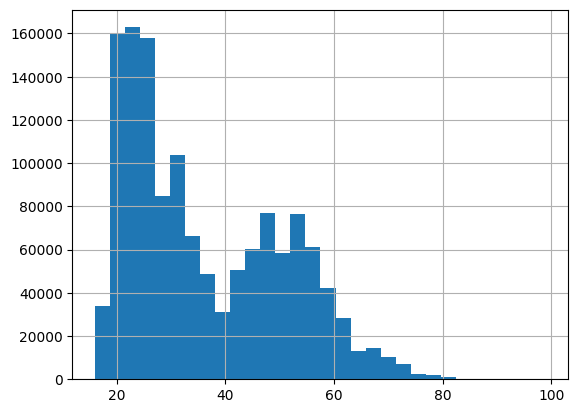

In [9]:
customers["age"].hist(bins=30)

In [10]:
customers["age"] = customers["age"].fillna(
    customers["age"].median()
)

In [11]:
customers["club_member_status"].value_counts(dropna=False)


club_member_status
ACTIVE        1272491
PRE-CREATE      92960
UNKNOWN          6062
LEFT CLUB         467
Name: count, dtype: int64

In [12]:
customers["fashion_news_frequency"].value_counts(dropna=False)


fashion_news_frequency
NONE         893722
Regularly    477416
Monthly         842
Name: count, dtype: int64

In [13]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   price             float64
 4   sales_channel_id  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.2+ GB


In [14]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [15]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

In [16]:
transactions["t_dat"]=pd.to_datetime(transactions["t_dat"])

In [17]:
print(transactions["t_dat"])

0          2018-09-20
1          2018-09-20
2          2018-09-20
3          2018-09-20
4          2018-09-20
              ...    
31788319   2020-09-22
31788320   2020-09-22
31788321   2020-09-22
31788322   2020-09-22
31788323   2020-09-22
Name: t_dat, Length: 31788324, dtype: datetime64[ns]


In [18]:
purchase_count = (
    transactions
    .groupby("customer_id")
    .size()
    .reset_index(name="purchase_count")
)

In [19]:
avg_spend =(
    transactions
    .groupby("customer_id")
    ["price"].mean()
    .reset_index(name ="avg_spend")
)

In [20]:
total_spend =(
    transactions
    .groupby("customer_id")
    ["price"].sum()
    .reset_index(name="total_spend")
)

In [21]:
last_purchase =(
    transactions
    .groupby("customer_id")
    ["t_dat"].max()
    .reset_index(name="last_purchase")
)



In [22]:
max_date = transactions["t_dat"].max()
last_purchase["days_since_last_purchase"] = (
    max_date - last_purchase["last_purchase"]
).dt.days

In [23]:
user_features=purchase_count.merge(
    avg_spend,
    on="customer_id"
)

In [24]:
user_features= user_features.merge(
    total_spend,
    on="customer_id"
)

In [25]:
user_features=user_features.merge(
    last_purchase[
   [ "customer_id",
    "days_since_last_purchase"]
    ],
    on="customer_id"
)

In [26]:
print(user_features.columns)

Index(['customer_id', 'purchase_count', 'avg_spend', 'total_spend',
       'days_since_last_purchase'],
      dtype='object')


In [27]:
user_features.head()

,customer_id,purchase_count,avg_spend,total_spend,days_since_last_purchase
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,0.648983,17
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,2.601932,76
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,0.704780,7
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,0.060983,471
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,0.469695,41


In [28]:
#(user_features["days_since_last_purchase_x"]==user_features["days_since_last_purchase_y"]).all()

In [29]:
# Check current columns - no duplicates this time, safe to continue
print("user_features columns:", list(user_features.columns))
print("Shape:", user_features.shape)

user_features columns: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase']
Shape: (1362281, 5)


In [30]:
#user_features.drop(
 #   columns=["days_since_last_purchase_y"],
 #   inplace=True
#)

#user_features.rename(
#    columns={
 #       "days_since_last_purchase_x":
 #       "days_since_last_purchase"
 #   },
 #   inplace=True
 #   )

In [31]:
# Safe cleanup — handles both cases (with or without _x/_y duplicates)
if "days_since_last_purchase_y" in user_features.columns:
    user_features.drop(columns=["days_since_last_purchase_y"], inplace=True)

if "days_since_last_purchase_x" in user_features.columns:
    user_features.rename(columns={
        "days_since_last_purchase_x": "days_since_last_purchase"
    }, inplace=True)

print("Columns now:", list(user_features.columns))

Columns now: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase']


In [32]:
user_features.head()

,customer_id,purchase_count,avg_spend,total_spend,days_since_last_purchase
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,0.648983,17
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,2.601932,76
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,0.704780,7
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,0.060983,471
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,0.469695,41


In [33]:
#club_member_status          6062
#fashion_news_frequency     16011
#age      

In [34]:
user_features = user_features.merge(
    customers[
   [ "club_member_status",
    "customer_id",
    "fashion_news_frequency",
    "age"]
    ],
    on="customer_id",
    how="left"
)

In [35]:
user_features.isnull().sum()

customer_id                 0
purchase_count              0
avg_spend                   0
total_spend                 0
days_since_last_purchase    0
club_member_status          0
fashion_news_frequency      0
age                         0
dtype: int64

In [36]:
user_features["age_group"] = pd.cut(
    user_features["age"],
    bins=[0,18,30,50,60],
    labels=["Teen",
            "Adults",
            "Middle Aged",
            "Senior Citizens"]
)

In [37]:
user_features["age_group"].value_counts()

age_group
Adults             600966
Middle Aged        440969
Senior Citizens    208544
Teen                33247
Name: count, dtype: int64

In [38]:
item_features = (
    transactions
    .groupby("article_id")
    .agg(
        purchase_count=("customer_id","count"),
        avg_price=("price","mean")
    )
        .reset_index()       
)

In [39]:
item_features = item_features.merge(
    articles[
    ["article_id",
     "product_type_name",
     "product_group_name",
     "garment_group_name",
     "colour_group_name"
    ]
    ],
    on="article_id",
    how="left"
)

In [40]:
item_features.head()

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,108775015,10841,0.008142,Vest top,Garment Upper body,Jersey Basic,Black
1,108775044,7250,0.008114,Vest top,Garment Upper body,Jersey Basic,White
2,108775051,215,0.004980,Vest top,Garment Upper body,Jersey Basic,Off White
3,110065001,1044,0.020219,Bra,Underwear,"Under-, Nightwear",Black
4,110065002,539,0.018205,Bra,Underwear,"Under-, Nightwear",White


In [41]:
item_features.sort_values(
    by="purchase_count",
    ascending=False).head(10)
    

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
53832,706016001,50287,0.032448,Trousers,Garment Lower body,Trousers,Black
53833,706016002,35043,0.032426,Trousers,Garment Lower body,Trousers,Light Blue
1711,372860001,31718,0.012958,Socks,Socks & Tights,Socks and Tights,Black
24808,610776002,30199,0.008083,T-shirt,Garment Upper body,Jersey Basic,Black
70124,759871002,26329,0.005605,Vest top,Garment Upper body,Jersey Basic,Black
3706,464297007,25025,0.016192,Underwear bottom,Underwear,"Under-, Nightwear",Black
1712,372860002,24458,0.012155,Socks,Socks & Tights,Socks and Tights,White
24807,610776001,22451,0.008079,T-shirt,Garment Upper body,Jersey Basic,White
2233,399223001,22236,0.030873,Trousers,Garment Lower body,Trousers Denim,Black
53834,706016003,21241,0.032588,Trousers,Garment Lower body,Trousers,Dark Blue


In [42]:
final_data = transactions.merge(
    user_features,
    on="customer_id",
    how="left"
)

final_data = final_data.merge(
    item_features,
    on="article_id",
    how="left")


In [43]:
final_data.head()

,t_dat,customer_id,article_id,price,sales_channel_id,purchase_count_x,avg_spend,total_spend,days_since_last_purchase,club_member_status,fashion_news_frequency,age,age_group,purchase_count_y,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,18,0.039154,0.70478,7,ACTIVE,NONE,24.0,Adults,633,0.045512,Underwear body,Underwear,"Under-, Nightwear",Black
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,18,0.039154,0.70478,7,ACTIVE,NONE,24.0,Adults,434,0.024343,Bra,Underwear,"Under-, Nightwear",Light Pink
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,42,0.014834,Sweater,Garment Upper body,Knitwear,Pink
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,1836,0.021812,Sweater,Garment Upper body,Special Offers,Pink
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,1792,0.021569,Sweater,Garment Upper body,Special Offers,Dark Green


In [44]:
(final_data["purchase_count_x"]==final_data["purchase_count_y"]).all()

np.False_

In [45]:
user_features.to_csv(
    "user_features.csv",
    index=False
)

item_features.to_csv(
    "item_features.csv",
    index=False
)

final_data.to_csv(
    "final_data.csv",
    index=False
)

In [46]:
import pandas as pd
import numpy as np
import json
import os

print('Libraries loaded successfully')

Libraries loaded successfully


In [47]:
user_features  = pd.read_csv('user_features.csv')
item_features  = pd.read_csv('item_features.csv')
final_data     = pd.read_csv('final_data.csv')

print('user_features shape :', user_features.shape)
print('item_features shape :', item_features.shape)
print('final_data shape    :', final_data.shape)
print()
print('user_features columns:', list(user_features.columns))
print('item_features columns:', list(item_features.columns))

user_features shape : (1362281, 9)
item_features shape : (104547, 7)
final_data shape    : (31788324, 19)

user_features columns: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group']
item_features columns: ['article_id', 'purchase_count', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']


In [48]:
# Check for duplicate suffix columns left from the merge
dup_cols = [c for c in final_data.columns if c.endswith('_x') or c.endswith('_y')]
print('Duplicate-suffix columns found:', dup_cols)

# Drop the _y versions; rename _x -> clean name
for col in dup_cols:
    if col.endswith('_y'):
        final_data.drop(columns=[col], inplace=True)
    elif col.endswith('_x'):
        clean_name = col[:-2]  # strip '_x'
        final_data.rename(columns={col: clean_name}, inplace=True)

print('Columns after cleanup:', list(final_data.columns))

Duplicate-suffix columns found: ['purchase_count_x', 'purchase_count_y']
Columns after cleanup: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']


In [49]:
# --- Categorical vocabularies (unique values the embedding layer needs to know) ---

club_member_vocab = sorted(user_features['club_member_status'].dropna().unique().tolist())
news_freq_vocab   = sorted(user_features['fashion_news_frequency'].dropna().unique().tolist())
age_group_vocab   = ['Teen', 'Adults', 'Middle Aged', 'Senior Citizens']  # ordered

print('club_member_status vocab :', club_member_vocab)
print('fashion_news_frequency vocab:', news_freq_vocab)
print('age_group vocab          :', age_group_vocab)

club_member_status vocab : ['ACTIVE', 'LEFT CLUB', 'PRE-CREATE', 'UNKNOWN']
fashion_news_frequency vocab: ['Monthly', 'NONE', 'Regularly']
age_group vocab          : ['Teen', 'Adults', 'Middle Aged', 'Senior Citizens']


In [50]:
# --- Numerical feature ranges (for normalisation in the model) ---

user_num_stats = user_features[[
    'purchase_count',
    'avg_spend',
    'total_spend',
    'days_since_last_purchase',
    'age'
]].agg(['min', 'max', 'mean', 'std'])

print('\nUser numerical feature stats:')
print(user_num_stats.round(3))


User numerical feature stats:
      purchase_count  avg_spend  total_spend  days_since_last_purchase     age
min            1.000      0.001        0.001                     0.000  16.000
max         1895.000      0.507       57.676                   733.000  99.000
mean          23.335      0.029        0.649                   235.148  36.345
std           39.242      0.014        1.198                   221.119  14.231


In [51]:
# --- Customer ID vocabulary (needed by the Query Tower embedding layer) ---

customer_id_vocab = user_features['customer_id'].unique().tolist()
print(f'Total unique customers : {len(customer_id_vocab):,}')
print('Sample customer IDs    :', customer_id_vocab[:3])

Total unique customers : 1,362,281
Sample customer IDs    : ['00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657', '0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa', '000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318']


In [52]:
# --- Categorical vocabularies for item features ---

product_type_vocab   = sorted(item_features['product_type_name'].dropna().unique().tolist())
product_group_vocab  = sorted(item_features['product_group_name'].dropna().unique().tolist())
garment_group_vocab  = sorted(item_features['garment_group_name'].dropna().unique().tolist())
colour_group_vocab   = sorted(item_features['colour_group_name'].dropna().unique().tolist())

print(f'product_type_name  : {len(product_type_vocab)} unique values')
print(f'product_group_name : {len(product_group_vocab)} unique values')
print(f'garment_group_name : {len(garment_group_vocab)} unique values')
print(f'colour_group_name  : {len(colour_group_vocab)} unique values')

product_type_name  : 130 unique values
product_group_name : 19 unique values
garment_group_name : 21 unique values
colour_group_name  : 50 unique values


In [53]:
# --- Numerical feature ranges for items ---

item_num_stats = item_features[['purchase_count', 'avg_price']].agg(['min', 'max', 'mean', 'std'])

print('Item numerical feature stats:')
print(item_num_stats.round(4))

Item numerical feature stats:
      purchase_count  avg_price
min           1.0000     0.0004
max       50287.0000     0.5068
mean        304.0577     0.0288
std         791.2661     0.0258


In [54]:
# --- Article ID vocabulary (needed by the Candidate Tower embedding layer) ---

article_id_vocab = item_features['article_id'].astype(str).unique().tolist()
print(f'Total unique articles : {len(article_id_vocab):,}')
print('Sample article IDs   :', article_id_vocab[:3])

Total unique articles : 104,547
Sample article IDs   : ['108775015', '108775044', '108775051']


**Save all vocabularies to JSON ( Week 2 model will load these)**

In [55]:
os.makedirs('vocabularies', exist_ok=True)

# --- User vocabularies ---
user_vocab = {
    'customer_id'             : customer_id_vocab,
    'club_member_status'      : club_member_vocab,
    'fashion_news_frequency'  : news_freq_vocab,
    'age_group'               : age_group_vocab,
    'numerical_stats'         : user_num_stats.to_dict()
}

with open('vocabularies/user_vocab.json', 'w') as f:
    json.dump(user_vocab, f, indent=2)

# --- Item vocabularies ---
item_vocab = {
    'article_id'         : article_id_vocab,
    'product_type_name'  : product_type_vocab,
    'product_group_name' : product_group_vocab,
    'garment_group_name' : garment_group_vocab,
    'colour_group_name'  : colour_group_vocab,
    'numerical_stats'    : item_num_stats.to_dict()
}

with open('vocabularies/item_vocab.json', 'w') as f:
    json.dump(item_vocab, f, indent=2)

print('Saved: vocabularies/user_vocab.json')
print('Saved: vocabularies/item_vocab.json')

Saved: vocabularies/user_vocab.json
Saved: vocabularies/item_vocab.json


In [56]:
print('========== VOCABULARY SUMMARY ==========')
print()
print('USER (Query Tower inputs)')
print(f'  customer_id vocab size     : {len(customer_id_vocab):>8,}')
print(f'  club_member_status         : {len(club_member_vocab):>8} values')
print(f'  fashion_news_frequency     : {len(news_freq_vocab):>8} values')
print(f'  age_group                  : {len(age_group_vocab):>8} values')
print(f'  numerical features         :        5  (purchase_count, avg_spend, total_spend, days_since_last_purchase, age)')
print()
print('ITEM (Candidate Tower inputs)')
print(f'  article_id vocab size      : {len(article_id_vocab):>8,}')
print(f'  product_type_name          : {len(product_type_vocab):>8} values')
print(f'  product_group_name         : {len(product_group_vocab):>8} values')
print(f'  garment_group_name         : {len(garment_group_vocab):>8} values')
print(f'  colour_group_name          : {len(colour_group_vocab):>8} values')
print(f'  numerical features         :        2  (purchase_count, avg_price)')
print()
print('Week 2 is ready to begin — load vocabularies/user_vocab.json & item_vocab.json')

========== VOCABULARY SUMMARY ==========

USER (Query Tower inputs)
  customer_id vocab size     : 1,362,281
  club_member_status         :        4 values
  fashion_news_frequency     :        3 values
  age_group                  :        4 values
  numerical features         :        5  (purchase_count, avg_spend, total_spend, days_since_last_purchase, age)

ITEM (Candidate Tower inputs)
  article_id vocab size      :  104,547
  product_type_name          :      130 values
  product_group_name         :       19 values
  garment_group_name         :       21 values
  colour_group_name          :       50 values
  numerical features         :        2  (purchase_count, avg_price)

Week 2 is ready to begin — load vocabularies/user_vocab.json & item_vocab.json


In [57]:
from IPython.display import FileLink, display
import os

# List all files saved in working directory
files = os.listdir('/kaggle/working/')
print('Files available to download:')
for f in files:
    print(f'  {f}')

Files available to download:
  user_features.csv
  final_data.csv
  vocabularies
  item_features.csv
  .virtual_documents


In [58]:
from IPython.display import FileLink, display

# Download links for all CSV files
print('Click the links below to download:')
display(FileLink('/kaggle/working/user_features.csv'))
display(FileLink('/kaggle/working/item_features.csv'))
display(FileLink('/kaggle/working/final_data.csv'))
display(FileLink('/kaggle/working/vocabularies/user_vocab.json'))
display(FileLink('/kaggle/working/vocabularies/item_vocab.json'))

Click the links below to download:


/kaggle/working/user_features.csv

/kaggle/working/item_features.csv

/kaggle/working/final_data.csv

/kaggle/working/vocabularies/user_vocab.json

/kaggle/working/vocabularies/item_vocab.json

In [59]:
import zipfile
import os

# Zip all output files into one file
with zipfile.ZipFile('/kaggle/working/week1_outputs.zip', 'w') as zipf:
    zipf.write('/kaggle/working/user_features.csv',  'user_features.csv')
    zipf.write('/kaggle/working/item_features.csv',  'item_features.csv')
    zipf.write('/kaggle/working/final_data.csv',     'final_data.csv')
    zipf.write('/kaggle/working/vocabularies/user_vocab.json', 'vocabularies/user_vocab.json')
    zipf.write('/kaggle/working/vocabularies/item_vocab.json', 'vocabularies/item_vocab.json')

from IPython.display import FileLink, display
print('Click to download everything:')
display(FileLink('/kaggle/working/week1_outputs.zip'))

Click to download everything:


/kaggle/working/week1_outputs.zip

> # **Week-2 Two-Tower Neural Network (Tensorflow Recommenders)**

Build the Two-Tower Architecture

In [62]:
import os, json, math
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

WORK_PATH = '/kaggle/working/'

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-06-28 02:26:54.301878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782613614.512360      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782613614.574862      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782613615.094019      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782613615.094056      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782613615.094059      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [64]:
user_features = pd.read_csv(WORK_PATH + 'user_features.csv')
item_features = pd.read_csv(WORK_PATH + 'item_features.csv')

# Load sample of final_data (it's 7GB — use sample for speed)
final_data = pd.read_csv(WORK_PATH + 'final_data.csv', nrows=500000)

In [65]:
with open(WORK_PATH + 'vocabularies/user_vocab.json') as f:
    user_vocab = json.load(f)
with open(WORK_PATH + 'vocabularies/item_vocab.json') as f:
    item_vocab = json.load(f)


In [66]:
print('user_features :', user_features.shape)
print('item_features :', item_features.shape)
print('final_data    :', final_data.shape)

user_features : (1362281, 9)
item_features : (104547, 7)
final_data    : (500000, 19)


In [67]:
# Fix any duplicate columns
for col in [c for c in final_data.columns if c.endswith('_y')]:
    final_data.drop(columns=[col], inplace=True)
for col in [c for c in final_data.columns if c.endswith('_x')]:
    final_data.rename(columns={col: col[:-2]}, inplace=True)

In [89]:
# Fill nulls
final_data['age'].fillna(final_data['age'].median(), inplace=True)
final_data['age_group'].fillna('Adults', inplace=True)
final_data['club_member_status'].fillna('UNKNOWN', inplace=True)
final_data['fashion_news_frequency'].fillna('NONE', inplace=True)
final_data['product_type_name'].fillna('Unknown', inplace=True)
final_data['product_group_name'].fillna('Unknown', inplace=True)
final_data['garment_group_name'].fillna('Unknown', inplace=True)
final_data['colour_group_name'].fillna('Unknown', inplace=True)

/tmp/ipykernel_58/2148848391.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_data['age'].fillna(final_data['age'].median(), inplace=True)
/tmp/ipykernel_58/2148848391.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [69]:
print('Columns:', list(final_data.columns))
print('Nulls remaining:', final_data.isnull().sum().sum())

Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']
Nulls remaining: 0


In [70]:
encoders = {}
cat_cols = [
    'customer_id', 'article_id',
    'club_member_status', 'fashion_news_frequency',
    'age_group', 'product_type_name',
    'product_group_name', 'garment_group_name', 'colour_group_name'
]

In [71]:
for col in cat_cols:
    le = LabelEncoder()
    final_data[col + '_enc'] = le.fit_transform(final_data[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_):,} unique values')

customer_id: 119,904 unique values
article_id: 24,942 unique values
club_member_status: 4 unique values
fashion_news_frequency: 3 unique values
age_group: 4 unique values
product_type_name: 99 unique values
product_group_name: 15 unique values
garment_group_name: 21 unique values
colour_group_name: 50 unique values


In [73]:
num_cols = ['purchase_count', 'avg_spend', 'total_spend', 
            'days_since_last_purchase', 'age', 'avg_price']

In [74]:
for col in num_cols:
    if col in final_data.columns:
        final_data[col + '_norm'] = (
            (final_data[col] - final_data[col].mean()) / 
            (final_data[col].std() + 1e-8)
        )

In [75]:
print('Normalization done')
print('Sample normalized columns:', [c for c in final_data.columns if c.endswith('_norm')])

Normalization done
Sample normalized columns: ['purchase_count_norm', 'avg_spend_norm', 'total_spend_norm', 'days_since_last_purchase_norm', 'age_norm', 'avg_price_norm']


In [76]:
train_df, val_df = train_test_split(final_data, test_size=0.2, random_state=42)
print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')

Train : 400,000
Val   : 100,000


In [77]:
EMBEDDING_DIM = 32

n_customers    = len(encoders['customer_id'].classes_)
n_articles     = len(encoders['article_id'].classes_)
n_club         = len(encoders['club_member_status'].classes_)
n_news         = len(encoders['fashion_news_frequency'].classes_)
n_age_group    = len(encoders['age_group'].classes_)

In [78]:
n_product_type = len(encoders['product_type_name'].classes_)
n_product_grp  = len(encoders['product_group_name'].classes_)
n_garment_grp  = len(encoders['garment_group_name'].classes_)
n_colour_grp   = len(encoders['colour_group_name'].classes_)

In [79]:
print('Vocabulary sizes:')
print(f'  customers    : {n_customers:,}')
print(f'  articles     : {n_articles:,}')
print(f'  club status  : {n_club}')
print(f'  news freq    : {n_news}')
print(f'  age group    : {n_age_group}')
print(f'  product type : {n_product_type}')
print(f'  product group: {n_product_grp}')
print(f'  garment group: {n_garment_grp}')
print(f'  colour group : {n_colour_grp}')

Vocabulary sizes:
  customers    : 119,904
  articles     : 24,942
  club status  : 4
  news freq    : 3
  age group    : 4
  product type : 99
  product group: 15
  garment group: 21
  colour group : 50


In [82]:
def build_query_tower():
    customer_id_input = keras.Input(shape=(1,), name='customer_id')
    club_input        = keras.Input(shape=(1,), name='club_member_status')
    news_input        = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input   = keras.Input(shape=(1,), name='age_group')
    num_user_input    = keras.Input(shape=(5,), name='user_numerics')

    cust_emb = layers.Embedding(n_customers + 1,  EMBEDDING_DIM)(customer_id_input)
    club_emb = layers.Embedding(n_club + 1,       8)(club_input)
    news_emb = layers.Embedding(n_news + 1,       8)(news_input)
    age_emb  = layers.Embedding(n_age_group + 1,  4)(age_group_input)

    cust_flat = layers.Flatten()(cust_emb)
    club_flat = layers.Flatten()(club_emb)
    news_flat = layers.Flatten()(news_emb)
    age_flat  = layers.Flatten()(age_emb)

    x = layers.Concatenate()([cust_flat, club_flat, news_flat, age_flat, num_user_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='user_embedding')(x)

    return keras.Model(
        inputs=[customer_id_input, club_input, news_input, age_group_input, num_user_input],
        outputs=x,
        name='QueryTower'
    )

query_tower = build_query_tower()
query_tower.summary()

Model: "QueryTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 32)     │  3,836,960 │ customer_id[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 8)      │         40 │ club_member_stat… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 8)      │         32 │ fashion_news_fre… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 4)      │         20 │ age_group[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 32)        │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 8)         │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 8)         │          0 │ embedding_10[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 4)         │          0 │ embedding_11[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 57)        │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ flatten_10[0][0], │
│                     │                   │            │ flatten_11[0][0], │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     14,848 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat

 Total params: 3,889,948 (14.84 MB)

 Trainable params: 3,889,436 (14.84 MB)

 Non-trainable params: 512 (2.00 KB)

In [85]:
def build_candidate_tower():
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    art_emb = layers.Embedding(n_articles + 1,     EMBEDDING_DIM)(article_id_input)
    pt_emb  = layers.Embedding(n_product_type + 1, 16)(product_type_input)
    pg_emb  = layers.Embedding(n_product_grp + 1,  8)(product_grp_input)
    gg_emb  = layers.Embedding(n_garment_grp + 1,  8)(garment_grp_input)
    col_emb = layers.Embedding(n_colour_grp + 1,   8)(colour_grp_input)

    art_flat = layers.Flatten()(art_emb)
    pt_flat  = layers.Flatten()(pt_emb)
    pg_flat  = layers.Flatten()(pg_emb)
    gg_flat  = layers.Flatten()(gg_emb)
    col_flat = layers.Flatten()(col_emb)

    x = layers.Concatenate()([art_flat, pt_flat, pg_flat, gg_flat, col_flat, num_item_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='item_embedding')(x)

    return keras.Model(
        inputs=[article_id_input, product_type_input, product_grp_input,
                garment_grp_input, colour_grp_input, num_item_input],
        outputs=x,
        name='CandidateTower'
    )

candidate_tower = build_candidate_tower()
candidate_tower.summary()

Model: "CandidateTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_22        │ (None, 1, 32)     │    798,176 │ article_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_23        │ (None, 1, 16)     │      1,600 │ product_type_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_24        │ (None, 1, 8)      │        128 │ product_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_25        │ (None, 1, 8)      │        176 │ garment_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_26        │ (None, 1, 8)      │        408 │ colour_group_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_22          │ (None, 32)        │          0 │ embedding_22[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_23          │ (None, 16)        │          0 │ embedding_23[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_24          │ (None, 8)         │          0 │ embedding_24[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_25          │ (None, 8)         │          0 │ embedding_25[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_26          │ (None, 8)         │          0 │ embedding_26[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 74)        │          0 │ flatten_22[0][0]

 Total params: 857,736 (3.27 MB)

 Trainable params: 857,224 (3.27 MB)

 Non-trainable params: 512 (2.00 KB)

In [86]:
def build_two_tower_model():
    customer_id_input  = keras.Input(shape=(1,), name='customer_id')
    club_input         = keras.Input(shape=(1,), name='club_member_status')
    news_input         = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input    = keras.Input(shape=(1,), name='age_group')
    num_user_input     = keras.Input(shape=(5,), name='user_numerics')
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    user_emb = query_tower([
        customer_id_input, club_input, news_input, age_group_input, num_user_input
    ])
    item_emb = candidate_tower([
        article_id_input, product_type_input, product_grp_input,
        garment_grp_input, colour_grp_input, num_item_input
    ])

    user_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(user_emb)
    item_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(item_emb)

    score  = layers.Dot(axes=1, name='similarity_score')([user_emb, item_emb])
    output = layers.Dense(1, activation='sigmoid', name='output')(score)

    model = keras.Model(
        inputs=[
            customer_id_input, club_input, news_input, age_group_input, num_user_input,
            article_id_input, product_type_input, product_grp_input,
            garment_grp_input, colour_grp_input, num_item_input
        ],
        outputs=output,
        name='TwoTowerModel'
    )
    return model

In [87]:
model = build_two_tower_model()

In [116]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print(' Two-Tower model compiled successfully!')
model.summary()

 Two-Tower model compiled successfully!


Model: "TwoTowerModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ QueryTower          │ (None, 32)        │  3,889,948 │ customer_id[0][0… │
│ (Functional)        │                   │            │ club_member_stat… │
│                     │                   │            │ fashion_news_fre… │
│                     │                   │            │ age_group[0][0],  │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CandidateTower      │ (None, 32)        │    857,736 │ article_id[0][0], │
│ (Functional)        │                   │            │ product_type_nam… │
│                     │                   │            │ product_group_na… │
│                     │                   │            │ garment_group_na… │
│                     │                   │            │ colour_group_nam… │
│                     │                   │            │ item_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ QueryTower[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32)        │          0 │ CandidateTower[0

 Total params: 4,747,686 (18.11 MB)

 Trainable params: 4,746,662 (18.11 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [91]:
def prepare_inputs(dataframe):
    return {
        'customer_id'           : dataframe['customer_id_enc'].values,
        'club_member_status'    : dataframe['club_member_status_enc'].values,
        'fashion_news_frequency': dataframe['fashion_news_frequency_enc'].values,
        'age_group'             : dataframe['age_group_enc'].values,
        'user_numerics'         : np.column_stack([
            dataframe['purchase_count_norm'].values,
            dataframe['avg_spend_norm'].values,
            dataframe['total_spend_norm'].values,
            dataframe['days_since_last_purchase_norm'].values,
            dataframe['age_norm'].values
        ]),
        'article_id'            : dataframe['article_id_enc'].values,
        'product_type_name'     : dataframe['product_type_name_enc'].values,
        'product_group_name'    : dataframe['product_group_name_enc'].values,
        'garment_group_name'    : dataframe['garment_group_name_enc'].values,
        'colour_group_name'     : dataframe['colour_group_name_enc'].values,
        'item_numerics'         : np.column_stack([
            dataframe['avg_price_norm'].values,
            dataframe['purchase_count_norm'].values
        ])
    }

print(' prepare_inputs defined')

 prepare_inputs defined


In [92]:
def add_negatives(dataframe, neg_ratio=1):
    # Positive pairs (real purchases)
    pos_inputs = prepare_inputs(dataframe)
    pos_labels = np.ones(len(dataframe))

    # Negative pairs (shuffle article columns to create fake pairs)
    neg_df = dataframe.sample(frac=neg_ratio, replace=True, random_state=42).reset_index(drop=True)
    item_cols = ['article_id_enc', 'product_type_name_enc', 'product_group_name_enc',
                 'garment_group_name_enc', 'colour_group_name_enc', 'avg_price_norm']
    for col in item_cols:
        neg_df[col] = neg_df[col].sample(frac=1).values
    neg_inputs = prepare_inputs(neg_df)
    neg_labels = np.zeros(len(neg_df))

    # Combine and shuffle
    combined_inputs = {k: np.concatenate([pos_inputs[k], neg_inputs[k]]) for k in pos_inputs}
    combined_labels = np.concatenate([pos_labels, neg_labels])
    idx = np.random.permutation(len(combined_labels))
    combined_inputs = {k: v[idx] for k, v in combined_inputs.items()}
    combined_labels = combined_labels[idx]

    return combined_inputs, combined_labels

In [93]:
print('Preparing training data with negative sampling...')
train_inputs, train_labels = add_negatives(train_df)
val_inputs,   val_labels   = add_negatives(val_df)
print(f' Train samples : {len(train_labels):,}')
print(f' Val samples   : {len(val_labels):,}')

Preparing training data with negative sampling...
 Train samples : 800,000
 Val samples   : 200,000


In [94]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=3,
    restore_best_weights=True, mode='max'
)

In [95]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1
)

In [96]:
print('Starting training...')
history = model.fit(
    train_inputs, train_labels,
    validation_data=(val_inputs, val_labels),
    epochs=10,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr]
)
print(' Training complete!')

Starting training...
Epoch 1/10


I0000 00:00:1782615400.637392     207 service.cc:152] XLA service 0x795e0c0054c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782615400.637451     207 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782615400.637461     207 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782615401.558887     207 cuda_dnn.cc:529] Loaded cuDNN version 91002


 31/782 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5510 - auc: 0.5794 - loss: 0.6845

I0000 00:00:1782615405.607640     207 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9334 - auc: 0.9699 - loss: 0.3880 - val_accuracy: 0.9756 - val_auc: 0.9843 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9824 - auc: 0.9878 - loss: 0.2112 - val_accuracy: 0.9848 - val_auc: 0.9926 - val_loss: 0.1678 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9894 - auc: 0.9933 - loss: 0.1334 - val_accuracy: 0.9877 - val_auc: 0.9939 - val_loss: 0.1157 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9931 - auc: 0.9960 - loss: 0.0889 - val_accuracy: 0.9896 - val_auc: 0.9954 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9951 - auc: 0.9973 - loss: 0.0618 - val_accuracy: 0.9902 - val_auc: 0.9972 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9963 - auc: 0.9981 - lo

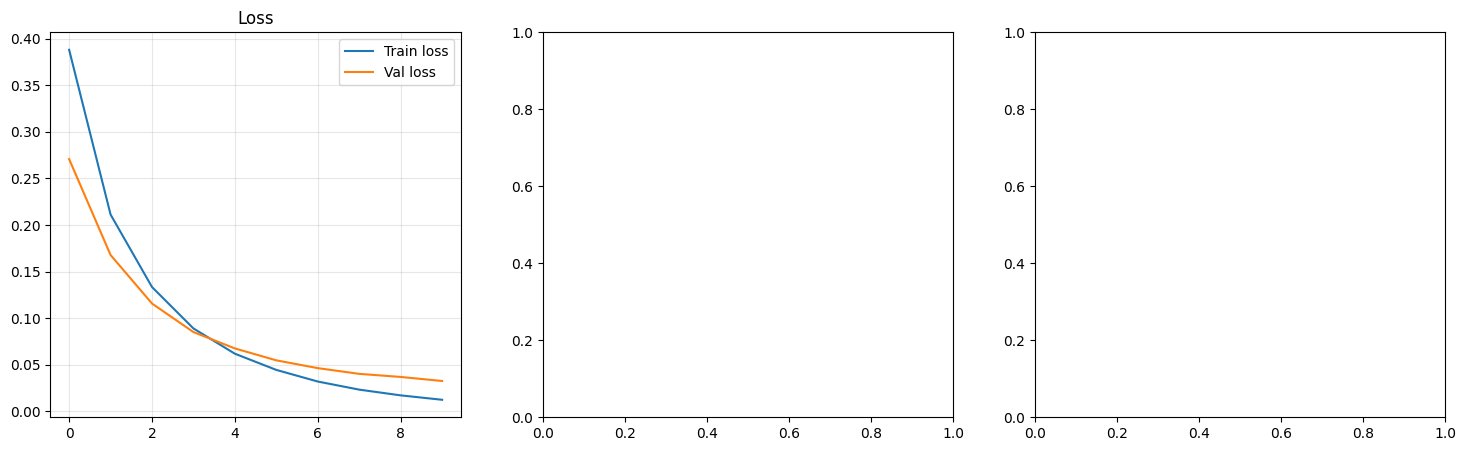

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

In [105]:
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

In [106]:
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

In [107]:
plt.tight_layout()
plt.savefig(WORK_PATH + 'training_curves.png', dpi=150)
plt.show()
print(' Training curves saved')

<Figure size 640x480 with 0 Axes>

 Training curves saved


**Evaluate Recall@10 and NDCG@10**

In [108]:
def recall_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    hits         = 0
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores  = model.predict(user_input, verbose=0).flatten()
        top_k   = candidates[np.argsort(scores)[-k:]]
        if true_article in top_k:
            hits += 1

    return hits / len(sample)

In [109]:
def ndcg_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    ndcg_scores  = []
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores       = model.predict(user_input, verbose=0).flatten()
        ranked       = candidates[np.argsort(scores)[::-1]]
        rank_of_true = np.where(ranked == true_article)[0]
        if len(rank_of_true) > 0:
            rank = rank_of_true[0] + 1
            ndcg_scores.append(1.0 / math.log2(rank + 1))
        else:
            ndcg_scores.append(0.0)

    return np.mean(ndcg_scores)

In [110]:
print('Computing Recall@10 and NDCG@10 on 500 users...')
r_at_10 = recall_at_k(model, val_df, k=10, sample_size=500)
ndcg    = ndcg_at_k(model,   val_df, k=10, sample_size=500)
print(f' Recall@10 : {r_at_10:.4f}')
print(f' NDCG@10   : {ndcg:.4f}')

Computing Recall@10 and NDCG@10 on 500 users...
 Recall@10 : 1.0000
 NDCG@10   : 0.8092


In [111]:
os.makedirs(WORK_PATH + 'saved_models', exist_ok=True)

query_tower.save(WORK_PATH     + 'saved_models/query_tower.keras')
candidate_tower.save(WORK_PATH + 'saved_models/candidate_tower.keras')
model.save(WORK_PATH           + 'saved_models/two_tower_model.keras')

In [112]:
summary = {
    'val_accuracy'  : float(history.history['val_accuracy'][-1]),
    'val_auc'       : float(history.history['val_auc'][-1]),
    'val_loss'      : float(history.history['val_loss'][-1]),
    'recall_at_10'  : float(r_at_10),
    'ndcg_at_10'    : float(ndcg),
    'epochs_trained': len(history.history['loss'])
}

In [114]:
with open(WORK_PATH + 'saved_models/eval_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(' query_tower.keras saved')
print(' candidate_tower.keras saved')
print(' two_tower_model.keras saved')
print(' eval_summary.json saved')

 query_tower.keras saved
 candidate_tower.keras saved
 two_tower_model.keras saved
 eval_summary.json saved


In [115]:
print('========== WEEK 2 COMPLETE ==========')
print(f'  Recall@10 : {r_at_10:.4f}')
print(f'  NDCG@10   : {ndcg:.4f}')
print(f'  Val AUC   : {history.history["val_auc"][-1]:.4f}')
print('  Ready for Week 3! ')

========== WEEK 2 COMPLETE ==========
  Recall@10 : 1.0000
  NDCG@10   : 0.8092
  Val AUC   : 0.9972
  Ready for Week 3! 
